In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches


In [2]:
db = duckdb.read_parquet(r"/data/input/piebro/changeset_data/year=*/month=*/*.parquet", hive_partitioning=1) 

In [3]:
pd.options.display.float_format = '{:20,.2f}'.format

In [5]:
df_total = pd.read_csv("../data/ouput/stats_total.csv").drop(columns={"Unnamed: 0"})

In [6]:
df_bot = duckdb.sql("""
    SELECT 
        CONCAT(year, '-', LPAD(CAST(month as VARCHAR), 2, '0')) as months,
        COUNT(DISTINCT user_name) as Contributors,
        CAST(SUM(edit_count) as BIGINT) as Edits,
        CAST(COUNT(*) AS INTEGER) as Changesets
    FROM db
    WHERE bot = true
    GROUP BY months 
    ORDER BY months DESC
""").df()

In [7]:
df_bot

,months,Contributors,Edits,Changesets
0,2026-03,15,101537,2963
1,2026-02,20,769168,3721
2,2026-01,19,89364,7841
3,2025-12,15,53198,2601
4,2025-11,15,165284,3095
...,...,...,...,...
189,2010-06,6,181708,5048
190,2010-05,8,442215,15566
191,2010-04,6,1644666,2104
192,2010-03,5,618902,2157


In [8]:
df_bot_20 = df_bot[df_bot["months"] >= "2020-01"]

In [9]:
df_bot_20 = df_bot_20.rename(columns={"Contributors": "ContributorsB", "Edits": "EditsB", "Changesets": "ChangesetsB" })

In [10]:
df_total_20 = df_total[df_total["months"] >= "2020-01"]

In [11]:
df_total_20

,months,Contributors,New Contributors,Edits,Changesets,Accumulated Contributors,Accumulated Edits,Accumulated Changesets
177,2020-01,44564,14489,102643410,1325907,"1,434,663.00","9,930,875,586.00","80,681,253.00"
178,2020-02,42391,13485,101472794,1236317,"1,448,148.00","10,032,348,380.00","81,917,570.00"
179,2020-03,40833,12860,125827885,1261810,"1,461,008.00","10,158,176,265.00","83,179,380.00"
180,2020-04,46585,17701,143702688,1550524,"1,478,709.00","10,301,878,953.00","84,729,904.00"
181,2020-05,50956,18143,142595125,1580513,"1,496,852.00","10,444,474,078.00","86,310,417.00"
...,...,...,...,...,...,...,...,...
247,2025-11,52241,15527,98291045,1295083,"2,393,376.00","18,011,112,402.00","175,666,313.00"
248,2025-12,49311,13371,111477725,1356404,"2,406,747.00","18,122,590,127.00","177,022,717.00"
249,2026-01,50428,14292,104456110,1258690,"2,421,039.00","18,227,046,237.00","178,281,407.00"
250,2026-02,49590,14990,105912350,1243619,"2,436,029.00","18,332,958,587.00","179,525,026.00"


In [12]:
df_merge = df_total_20.merge(df_bot_20, on ="months", how = "left")

In [13]:
df_merge

,months,Contributors,New Contributors,Edits,Changesets,Accumulated Contributors,Accumulated Edits,Accumulated Changesets,ContributorsB,EditsB,ChangesetsB
0,2020-01,44564,14489,102643410,1325907,"1,434,663.00","9,930,875,586.00","80,681,253.00",11,271452,4292
1,2020-02,42391,13485,101472794,1236317,"1,448,148.00","10,032,348,380.00","81,917,570.00",14,1017006,3613
2,2020-03,40833,12860,125827885,1261810,"1,461,008.00","10,158,176,265.00","83,179,380.00",13,510320,2815
3,2020-04,46585,17701,143702688,1550524,"1,478,709.00","10,301,878,953.00","84,729,904.00",12,646185,2056
4,2020-05,50956,18143,142595125,1580513,"1,496,852.00","10,444,474,078.00","86,310,417.00",15,961212,2884
...,...,...,...,...,...,...,...,...,...,...,...
70,2025-11,52241,15527,98291045,1295083,"2,393,376.00","18,011,112,402.00","175,666,313.00",15,165284,3095
71,2025-12,49311,13371,111477725,1356404,"2,406,747.00","18,122,590,127.00","177,022,717.00",15,53198,2601
72,2026-01,50428,14292,104456110,1258690,"2,421,039.00","18,227,046,237.00","178,281,407.00",19,89364,7841
73,2026-02,49590,14990,105912350,1243619,"2,436,029.00","18,332,958,587.00","179,525,026.00",20,769168,3721


In [14]:
df_merge["edit_percB"] = (df_merge["EditsB"] /df_merge["Edits"]) *100 

In [15]:
df_merge["contrib_percB"] = (df_merge["ContributorsB"] /df_merge["Contributors"]) *100 
df_merge["changeset_percB"] = (df_merge["ChangesetsB"] /df_merge["Changesets"]) *100 

In [25]:
df_merge = df_merge[df_merge["months"] <= "2025-12"]

In [22]:
df_merge.sort_values(by="edit_percB")

,months,Contributors,New Contributors,Edits,Changesets,Accumulated Contributors,Accumulated Edits,Accumulated Changesets,ContributorsB,EditsB,ChangesetsB,edit_percB,contrib_percB,changeset_percB
69,2025-10,51794,13930,101720286,1360811,"2,377,849.00","17,912,821,357.00","174,371,230.00",9,26466,1928,0.03,0.02,0.14
35,2022-12,41556,10912,96760328,1155518,"1,942,650.00","14,214,710,646.00","131,032,962.00",10,27628,1947,0.03,0.02,0.17
34,2022-11,48113,14402,111203332,1260261,"1,931,738.00","14,117,950,318.00","129,877,444.00",10,45090,3153,0.04,0.02,0.25
68,2025-09,51620,13657,101789392,1394191,"2,363,919.00","17,811,101,071.00","173,010,419.00",10,41830,2115,0.04,0.02,0.15
48,2024-01,43207,10978,132681274,1176644,"2,112,507.00","15,677,179,118.00","147,228,871.00",15,56352,3893,0.04,0.03,0.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,2020-12,45431,13808,134772348,1680966,"1,616,321.00","11,387,549,414.00","97,040,701.00",11,4214608,2165,3.13,0.02,0.13
26,2022-03,43967,12070,117859126,1218426,"1,827,688.00","13,278,244,066.00","119,473,865.00",15,4163080,3258,3.53,0.03,0.27
37,2023-02,48967,15383,119491322,1208846,"1,970,189.00","14,448,792,315.00","133,448,282.00",14,6115604,2404,5.12,0.03,0.20
28,2022-05,48307,13689,117146709,1385735,"1,853,708.00","13,500,519,998.00","122,081,980.00",14,6902956,54191,5.89,0.03,3.91


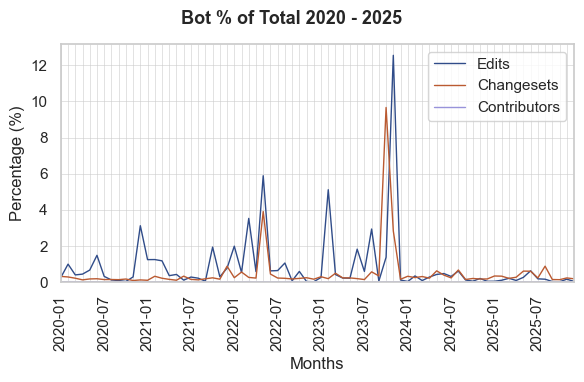

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.set_theme(style="whitegrid")
#sns.set_context("paper")
fig.suptitle("Bot % of Total 2020 - 2025", fontsize=13, fontweight="bold", y=0.95)

sns.lineplot(x = 'months',
         y='edit_percB',
         data=df_merge,
         linewidth=1,
         color = "#304C89",
         label = 'Edits')

sns.lineplot(x = 'months',
             y='changeset_percB',
             data=df_merge,
             linewidth=1,
             color = "#BA5A31",
             label = "Changesets"
            )

sns.lineplot(x = 'months',
             y='contrib_percB',
             data=df_merge,
             linewidth=1,
             color = "#9893DA",
             label = "Contributors"
            )

ax.set_ylabel("Percentage (%)")
ax.set_xlim('2020-01', '2025-12')
ax.grid(linewidth=0.4)

ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel('Months')
ax.set_ylim(0,)

# Hide every second x-axis tick label
for i, label in enumerate(ax.get_xticklabels()):
    if i % 6 != 0:
        label.set_visible(False)
        
fig.tight_layout()
fig.savefig("../results/Bot_percentage20_25_v2.png", bbox_inches="tight")
plt.show()

### Checking Bot and AI Overlap

In [19]:
df_ai_bot = duckdb.sql("""
    SELECT 
        CONCAT(year, '-', LPAD(CAST(month as VARCHAR), 2, '0')) as months,
        year,
        COUNT(DISTINCT user_name) as Contributors,
        CAST(SUM(edit_count) as BIGINT) as Edits,
        CAST(COUNT(*) AS INTEGER) as Changesets
    FROM db
    WHERE bot = true AND (
        created_by = 'Rapid' 
        OR array_to_string(source, ',') ILIKE '%microsoft/BuildingFootprints%'
        OR array_to_string(source, ',') ILIKE '%mapwithai%'
        OR array_to_string(source, ',') ILIKE '%esri/Google_Africa_Buildings%'
        OR array_to_string(source, ',') ILIKE '%esri/Google_Open_Buildings%'
        OR array_to_string(hashtags, ',') ILIKE '%mapwithai%'
        ) 
    GROUP BY months, year  
    ORDER BY months, year DESC
""").df()


In [20]:
df_ai_bot

,months,year,Contributors,Edits,Changesets
0,2024-06,2024,1,98,1
